## Methodology : 
- define global parameters
- presenting the beta and gamma heatmaps
- compute and simulate R0
- confirmation of asymptotic properties of R0 with respect to diffusion rates dE and dI
- solutions of time-dependent problem, with RO gt and lt 1 : make constat, verify with DFE

In [196]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [197]:
# setup
import numpy as np
import sys
from pathlib import Path
import seaborn as sb

# Add parent directory to path to import local modules
sys.path.insert(0, str(Path.cwd().parent))

from src.core.SEIRSParameters import*
from src.core.solvers import*
from src.core.utils import*

**Global parameters definition**

| Diffusion Rate | Value | Source |
| :--- | :--- | :--- |
| $d_S$ | 0.1 | Wang, J., et al. (2012). Spatiotemporal patterns of a SEIRS epidemic model with constant recruitment and delay. |
| $d_E$ | 0.1 | Wang, J., et al. (2012). Spatiotemporal patterns of a SEIRS epidemic model with constant recruitment and delay. |
| $d_I$ | 0.01 | Wang, J., et al. (2012). Spatiotemporal patterns of a SEIRS epidemic model with constant recruitment and delay. |
| $d_R$ | 0.1 | Wang, J., et al. (2012). Spatiotemporal patterns of a SEIRS epidemic model with constant recruitment and delay. |

In [198]:
n = 20 # grid size (number of nodes in each dimension); we'll use a smaller value for quick implementtion

# diffusion rates
DS = 0.1
DE = 0.1
DI = 0.1
DR = 0.1

ALPHA = 0.1
SIGMA = 0.25

BETA_0 = 0.3
GAMMA_0 = 0.3

GAMMA_COEFF = BETA_COEFF = 1e-3


POPULATION_DENSITY = 1.0 # N
OMEGA = 1.0 # space volume in 2D 
M=n*n

baseParams = SEIRSParameters(
    dS=DS,
    dE=DE,
    dI=DI,
    dR=DR,
    N=POPULATION_DENSITY,
    grid_size=n,
    alpha=ALPHA,
    sigma=SIGMA,
    beta_0=BETA_0,
    gamma_0=GAMMA_0,
    gamma_coeff=GAMMA_COEFF,
    beta_coeff=BETA_COEFF
)

**Plotting the beta and gamma maps**

In [199]:
# Gaussian parameters
R_GAMMA = 0.1 # radius/width
R_BETA = 0.1
C_GAMMA = (0.25, 0.25) # center
C_BETA = (0.75, 0.75)

In [200]:
beta_field = baseParams.beta_field(mu=C_BETA, sigma=R_BETA)
gamma_field = baseParams.gamma_field(mu=C_GAMMA, sigma=R_GAMMA)

In [201]:
# 2D heatmap helper for spatial fields
TITLE_KW   = dict(fontsize=11, fontweight='bold', color='#000000', pad=10)    
LABEL_KW   = dict(fontsize=9,  color='#000000')
TICK_KW    = dict(colors='#000000', labelsize=8)

def plot_heatmap(field, title='', xlabel='x', ylabel='y', cmap='viridis', cbar_label=None, center=None, radius=None, circle_edgecolor='#ff3333'):
    """Plot a 2D spatial field using seaborn/matplotlib with publication-ready styling.

    Parameters
    - field: 2D array (ny, nx)
    - title, xlabel, ylabel: labels
    - cmap: colormap
    - cbar_label: colorbar label (if None, will use title)
    - center: tuple (x, y) in normalized coordinates [0,1] to mark with a dot and circle
    - radius: float in normalized coordinates [0,1] for the circle radius
    - circle_edgecolor: color for the circle/point marker
    """
    # Local import of matplotlib to avoid top-level matplotlib import
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches

    # Use seaborn theme for publication-ready plots
    sb.set_theme(style='white', context='talk', rc={'axes.edgecolor': '#333333', 'figure.dpi': 100})

    field = np.asarray(field)
    ny, nx = field.shape

    fig, ax = plt.subplots(figsize=(7, 6), dpi=100)
    fig.patch.set_facecolor('#ffffff')
    ax.set_facecolor('#ffffff')

    # Show the field in normalized coordinates [0,1] so centers/radii map directly
    im = ax.imshow(field, cmap=cmap, origin='lower', extent=(0.0, 1.0, 0.0, 1.0), aspect='equal', interpolation='nearest')

    # Colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label or title, **LABEL_KW)
    cbar.ax.yaxis.set_tick_params(**TICK_KW)

    # Graduations / ticks: show 0.0, 0.25, 0.5, 0.75, 1.0
    major_ticks = np.linspace(0.0, 1.0, 5)
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)
    ax.set_xticklabels([f"{t:.2f}" for t in major_ticks], **LABEL_KW)
    ax.set_yticklabels([f"{t:.2f}" for t in major_ticks], **LABEL_KW)
    ax.grid(which='major', color='#dddddd', linestyle='--', linewidth=0.8, alpha=0.8)

    # Apply labels and styling
    ax.set_title(title, loc='center', **TITLE_KW)
    ax.set_xlabel(xlabel, **LABEL_KW)
    ax.set_ylabel(ylabel, **LABEL_KW)
    ax.tick_params(axis='both', **TICK_KW)

    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

    # Draw center and circle if provided (center in normalized [0,1] coordinates)
    if center is not None and radius is not None:
        try:
            cx, cy = float(center[0]), float(center[1])
            r = float(radius)
            # Draw circle (not filled)
            circle = patches.Circle((cx, cy), r, fill=False, edgecolor=circle_edgecolor, linewidth=2, alpha=0.9)
            ax.add_patch(circle)
            # Draw center point
            ax.plot(cx, cy, marker='o', color=circle_edgecolor, markersize=6)
        except Exception:
            pass

    return fig, ax, im


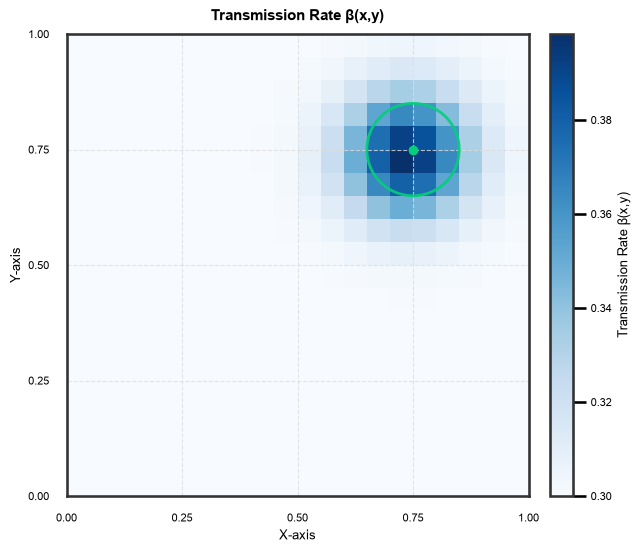

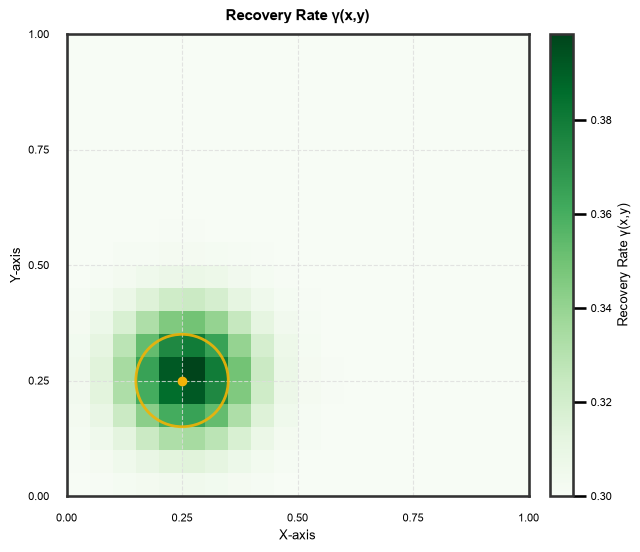

In [202]:
# ploting heatmaps of beta and gamma
output_dir = Path.cwd().parent / "outputs" / "figures" / "nb1"
output_dir.mkdir(parents=True, exist_ok=True)

fig_beta, ax_beta, _ = plot_heatmap(
    beta_field,
    title='Transmission Rate β(x,y)',
    xlabel='X-axis',
    ylabel='Y-axis',
    cmap='Blues',
    center=C_BETA,
    radius=R_BETA,
    circle_edgecolor="#04CF7B"
)
fig_beta.savefig(output_dir / "beta_field.png", dpi=200, bbox_inches='tight')

fig_gamma, ax_gamma, _ = plot_heatmap(
    gamma_field,
    title='Recovery Rate γ(x,y)',
    xlabel='X-axis',
    ylabel='Y-axis',
    cmap='Greens',
    center=C_GAMMA,
    radius=R_GAMMA,
    circle_edgecolor="#F1B307"
)
fig_gamma.savefig(output_dir / "gamma_field.png", dpi=200, bbox_inches='tight')


**Computing and simulate R0**

In [203]:
mu_star = compute_mu_star(baseParams, beta_field=beta_field, gamma_field=gamma_field)
R0 = POPULATION_DENSITY / (mu_star * OMEGA)

In [204]:
print(f"Population density N : {POPULATION_DENSITY}")
print(f"R0 : {R0}")
print(f"Mu star : {mu_star}")

print("Calibration: N required for different target ℛ₀")
print("-" * 45)
for R0_target in np.arange(0.10, 5.00, 0.50):
    N_needed = R0_target * mu_star * OMEGA
    print(f"  ℛ₀ = {R0_target:.2f}  →  N = {N_needed:.6f}")
print()

Population density N : 1.0
R0 : 0.003455947819761645
Mu star : 289.3562206818764
Calibration: N required for different target ℛ₀
---------------------------------------------
  ℛ₀ = 0.10  →  N = 28.935622
  ℛ₀ = 0.60  →  N = 173.613732
  ℛ₀ = 1.10  →  N = 318.291843
  ℛ₀ = 1.60  →  N = 462.969953
  ℛ₀ = 2.10  →  N = 607.648063
  ℛ₀ = 2.60  →  N = 752.326174
  ℛ₀ = 3.10  →  N = 897.004284
  ℛ₀ = 3.60  →  N = 1041.682394
  ℛ₀ = 4.10  →  N = 1186.360505
  ℛ₀ = 4.60  →  N = 1331.038615



**Confirmation of asymptotic properties of R0 with respect to diffusion rates dE and dI** (Castellano et al.) (Let that for later)

**Solutions of time-dependent problem, with RO gt and lt 1 : make constat, verify with DFE**

In [205]:
N1 = 0.65 * mu_star # for case 1
N2 = 1.6 * mu_star # for case 2

print(f"Principal eigenvalue (mu_star): {mu_star}")
print(f"\nCase 1 : \nN = {N1}\nR0 = {N1 / (mu_star * 1.0)}")  # OMEGA = 1.0
print(f"\nCase 2 : \nN = {N2}\nR0 = {N2 / (mu_star * 1.0)}")

Principal eigenvalue (mu_star): 289.3562206818764

Case 1 : 
N = 188.08154344321966
R0 = 0.65

Case 2 : 
N = 462.96995309100225
R0 = 1.6


In [206]:
paramsCaseA = SEIRSParameters(
    dS=DS,
    dE=DE,
    dI=DI,
    dR=DR,
    N=N1,
    grid_size=n,
    alpha=ALPHA,
    sigma=SIGMA,
    beta_0=BETA_0,
    gamma_0=GAMMA_0,
    gamma_coeff=GAMMA_COEFF,
    beta_coeff=BETA_COEFF
)

paramsCaseB = SEIRSParameters(
    dS=DS,
    dE=DE,
    dI=DI,
    dR=DR,
    N=N2,
    grid_size=n,
    alpha=ALPHA,
    sigma=SIGMA,
    beta_0=BETA_0,
    gamma_0=GAMMA_0,
    gamma_coeff=GAMMA_COEFF,
    beta_coeff=BETA_COEFF
)

In [207]:
init1 = initial_conditions(paramsCaseA, center=C_BETA+(0.01, 0.01)) # near high-risk zone
init2 = initial_conditions(paramsCaseB, center=C_BETA+(0.01, 0.01))

In [208]:
u0 = initial_conditions(params=paramsCaseA)
print(f"S + E + I + R = {mass(u0[:M].reshape(n,n), paramsCaseA.h) + mass(u0[M:2*M].reshape(n,n), paramsCaseA.h) + mass(u0[2*M:3*M].reshape(n,n), paramsCaseA.h) + mass(u0[3*M:4*M].reshape(n,n), paramsCaseA.h) }")

S + E + I + R = 188.0815434432197


In [209]:
TIME_SPAN = (0, 100)  # time span for the simulation
TIME_EVAL = np.linspace(TIME_SPAN[0], TIME_SPAN[1], (TIME_SPAN[1] - TIME_SPAN[0])*10)  # time points where the solution is evaluated

In [210]:
res_simA = solve_seirs(
    t_span=TIME_SPAN,
    t_eval=TIME_EVAL,
    initial_conditions=init1,
    params=paramsCaseA,
    beta_field=beta_field, 
    gamma_field=gamma_field
)
print("Solver success for case A:", res_simA.success)

res_simB = solve_seirs(
    t_span=TIME_SPAN,
    t_eval=TIME_EVAL,
    initial_conditions=init2,
    params=paramsCaseB,
    beta_field=beta_field, 
    gamma_field=gamma_field
)
print("Solver success for case B:", res_simB.success)

Solver success for case A: True
Solver success for case B: True


In [211]:
def plot_scenario(res, scenario_name):
    """Plot time evolution of total population in each compartment for a single scenario using seaborn."""

    # Local import of matplotlib for figure management
    import matplotlib.pyplot as plt

    # Use seaborn theme for publication-ready time series
    sb.set_theme(style='whitegrid', context='talk', rc={'axes.edgecolor': '#333333'})

    t = res.t
    M = n * n

    # Each compartment is shape (M, n_timesteps)
    S = res.y[:M, :]
    E = res.y[M:2*M, :]
    I = res.y[2*M:3*M, :]
    R = res.y[3*M:, :]

    # Reshape to (N_GRID, N_GRID, n_timesteps)
    S_reshaped = S.reshape(n, n, -1)
    E_reshaped = E.reshape(n, n, -1)
    I_reshaped = I.reshape(n, n, -1)
    R_reshaped = R.reshape(n, n, -1)

    # Total population = sum over all grid points with trapezoidal weighting
    S_total = np.trapezoid(np.trapezoid(S_reshaped, dx=1/(n-1), axis=1), dx=1/(n-1), axis=0)
    E_total = np.trapezoid(np.trapezoid(E_reshaped, dx=1/(n-1), axis=1), dx=1/(n-1), axis=0)
    I_total = np.trapezoid(np.trapezoid(I_reshaped, dx=1/(n-1), axis=1), dx=1/(n-1), axis=0)
    R_total = np.trapezoid(np.trapezoid(R_reshaped, dx=1/(n-1), axis=1), dx=1/(n-1), axis=0)

    fig, ax = plt.subplots(figsize=(8, 5), dpi=100)

    # Plot using seaborn's lineplot for nicer defaults
    sb.lineplot(x=t, y=S_total, label='S', ax=ax, color='blue')
    sb.lineplot(x=t, y=E_total, label='E', ax=ax, color='orange')
    sb.lineplot(x=t, y=I_total, label='I', ax=ax, color='red')
    sb.lineplot(x=t, y=R_total, label='R', ax=ax, color='green')

    ax.set_xlabel('t', fontsize=11)
    ax.set_ylabel('N', fontsize=11)
    ax.set_title(f'Time Evolution - {scenario_name}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    fig.tight_layout()

    plt.show()
    plt.close(fig)


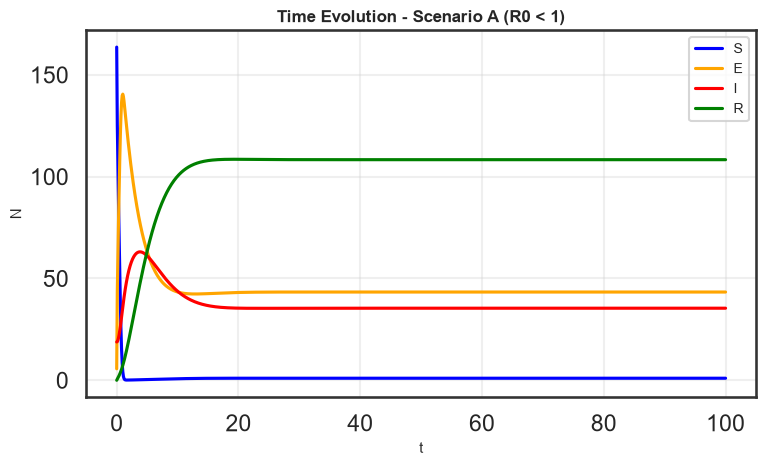

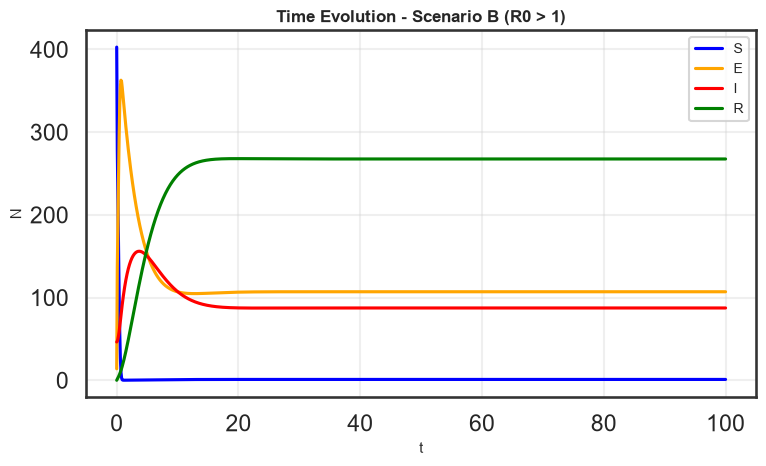

In [212]:
plot_scenario(res_simA, "Scenario A (R0 < 1)")
plot_scenario(res_simB, "Scenario B (R0 > 1)")